# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
import pandas as pd

df = pd.read_csv("/mnt/c/Users/pooja/Desktop/supersymmetry_dataset.csv", header=None)

/tmp/ipykernel_4250/4186107910.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/mnt/c/Users/pooja/Desktop/supersymmetry_dataset.csv", header=None)


In [2]:
df = pd.read_csv("/mnt/c/Users/pooja/Desktop/supersymmetry_dataset.csv", low_memory=False)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = "/mnt/c/Users/pooja/Desktop/supersymmetry_dataset.csv"

df = pd.read_csv(filename, dtype='float64', low_memory=False, header=0)

VarNames = df.columns.tolist()
print(VarNames)

['SUSY', 'lepton 1 pT', 'lepton 1 eta', 'lepton 1 phi', 'lepton 2 pT', 'lepton 2 eta', 'lepton 2 phi', 'missing energy magnitude', 'missing energy phi', 'MET_rel', 'axial MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos(theta_r1)']


In [4]:
import sklearn
print("it works")

it works


In [5]:
print(df.columns.tolist())

['SUSY', 'lepton 1 pT', 'lepton 1 eta', 'lepton 1 phi', 'lepton 2 pT', 'lepton 2 eta', 'lepton 2 phi', 'missing energy magnitude', 'missing energy phi', 'MET_rel', 'axial MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos(theta_r1)']


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [6]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train = 50000

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["SUSY"]

X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["SUSY"]

Test_sig = Test_Sample[Test_Sample["SUSY"]==1]
Test_bkg = Test_Sample[Test_Sample["SUSY"]==0]

We can train the classifier as follow:

In [8]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

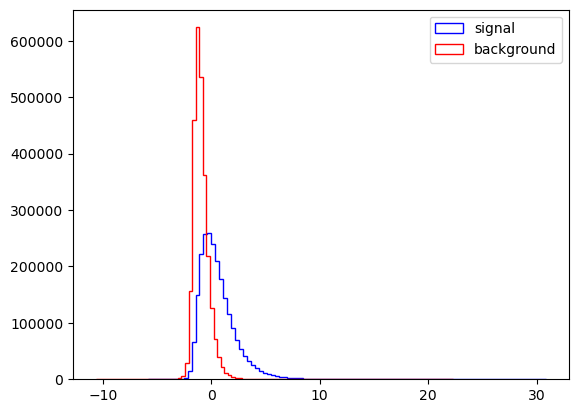

In [9]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

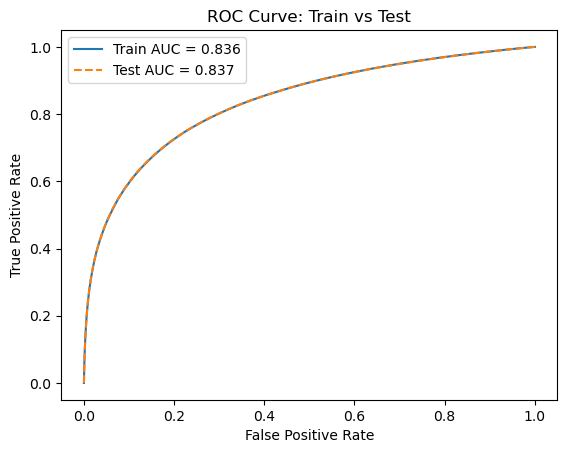

In [10]:
import sklearn.discriminant_analysis as DA
from sklearn.metrics import roc_curve, auc

# Set up train/test samples
N_Train = 1000000

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["SUSY"]

X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["SUSY"]

Test_sig = Test_Sample[Test_Sample["SUSY"]==1]
Test_bkg = Test_Sample[Test_Sample["SUSY"]==0]

# Train the Fisher/LDA classifier
Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

# Compute ROC for train and test
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

# Plot both ROC curves
plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.3f}", linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

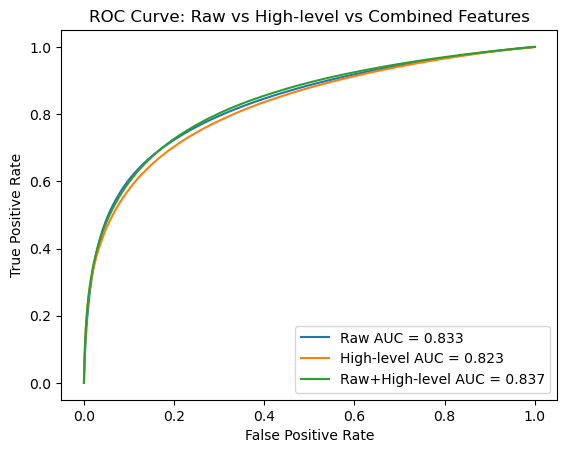

In [11]:
# Raw features (first 8 columns after SUSY)
raw_features = ["lepton 1 pT", "lepton 1 eta", "lepton 1 phi", "lepton 2 pT", "lepton 2 eta", "lepton 2 phi", "missing energy magnitude", "missing energy phi"]

# High-level features (remaining columns)
high_features = ["MET_rel", "axial MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos(theta_r1)"]

# All features combined
all_features = VarNames[1:]

plt.figure()

for features, label in [(raw_features, "Raw"), (high_features, "High-level"), (all_features, "Raw+High-level")]:
    Fisher_temp = DA.LinearDiscriminantAnalysis()
    Fisher_temp.fit(Train_Sample[features], y_Train)
    
    fpr, tpr, _ = roc_curve(y_Test, Fisher_temp.decision_function(Test_Sample[features]))
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{label} AUC = {roc_auc:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Raw vs High-level vs Combined Features")
plt.legend()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [12]:
## Exercise 4 Part a

#I selected the following 3 classifiers:
#1. Logistic Regression - simple linear classifier, good baseline
#2. Random Forest - ensemble of decision trees, handles non-linear patterns
#3. Gradient Boosting - strong performer on tabular data#

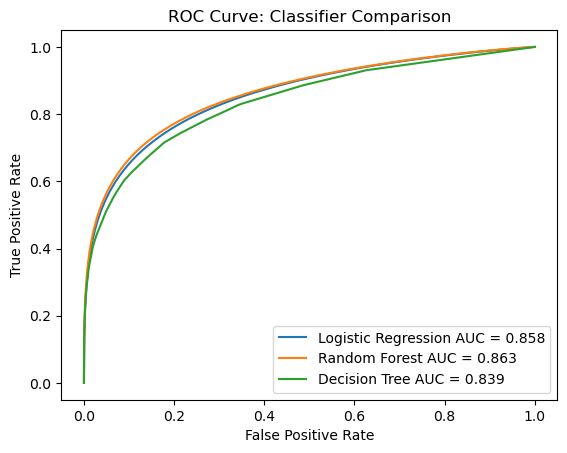

In [6]:
#Part (b)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

N_Train = 100000
Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]
X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["SUSY"]
X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["SUSY"]

def compare_classifier(clf, clf_name, features=VarNames[1:]):
    clf.fit(Train_Sample[features], y_Train)
    fpr, tpr, _ = roc_curve(y_Test, clf.predict_proba(Test_Sample[features])[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clf_name} AUC = {roc_auc:.3f}")
    return clf, roc_auc

plt.figure()
LR, auc_lr = compare_classifier(LogisticRegression(max_iter=1000), "Logistic Regression")
RF, auc_rf = compare_classifier(RandomForestClassifier(n_estimators=50, n_jobs=-1), "Random Forest")
DT, auc_dt = compare_classifier(DecisionTreeClassifier(max_depth=5), "Decision Tree")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Classifier Comparison")
plt.legend()
plt.show()

In [7]:
# Part c - Maximal significance using Logistic Regression
y_scores_lr = LR.predict_proba(X_Test)[:, 1]
fpr_c, tpr_c, thresholds_c = roc_curve(y_Test, y_scores_lr)

y_Test_arr = np.array(y_Test)

# Vectorized significance calculation
NS = (tpr_c * np.sum(y_Test_arr == 1))
NB = (fpr_c * np.sum(y_Test_arr == 0))
sig = np.where((NS + NB) > 0, NS / np.sqrt(NS + NB), 0)

max_sig = np.max(sig)
best_threshold = thresholds_c[np.argmax(sig)]

print(f"Max significance: {max_sig:.3f}")
print(f"Best threshold: {best_threshold:.3f}")

Max significance: 1142.022
Best threshold: 0.369


/tmp/ipykernel_4372/2997397100.py:10: RuntimeWarning: invalid value encountered in divide
  sig = np.where((NS + NB) > 0, NS / np.sqrt(NS + NB), 0)


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [ ]:
## Exercise 5 Part a

# - Precision: fraction of predicted positives that are truly positive (TP / (TP + FP))
# - Recall (TPR): fraction of actual positives correctly identified (TP / (TP + FN))
# - Accuracy: fraction of all predictions that are correct ((TP + TN) / total)
#- F1 Score: harmonic mean of precision and recall, balances both metrics (2 * precision * recall / (precision + recall))

In [8]:
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             accuracy_score, roc_curve, auc)
import pandas as pd
import numpy as np

# Use best classifier (Random Forest)
y_scores = RF.predict_proba(X_Test)[:, 1]
y_pred = RF.predict(X_Test)

# Standard metrics
precision = precision_score(y_Test, y_pred)
recall = recall_score(y_Test, y_pred)
f1 = f1_score(y_Test, y_pred)
accuracy = accuracy_score(y_Test, y_pred)

fpr, tpr, thresholds = roc_curve(y_Test, y_scores)
roc_auc = auc(fpr, tpr)

# FPR and TPR at default threshold (0.5)
fpr_val = 1 - precision  # approximate
tpr_val = recall

# Maximal significance
significances = []
for i, t in enumerate(thresholds):
    y_pred_t = (y_scores >= t).astype(int)
    NS = np.sum((y_pred_t == 1) & (y_Test == 1))
    NB = np.sum((y_pred_t == 1) & (y_Test == 0))
    sig = NS / np.sqrt(NS + NB) if (NS + NB) > 0 else 0
    significances.append(sig)

max_sig = max(significances)

# Nice table
results = pd.DataFrame({
    "Metric": ["TPR (Recall)", "FPR", "AUC", "Precision", "F1 Score", "Accuracy", "Max Significance"],
    "Value": [round(tpr_val, 4), round(fpr_val, 4), round(roc_auc, 4),
              round(precision, 4), round(f1, 4), round(accuracy, 4), round(max_sig, 4)]
})

print(results.to_string(index=False))

          Metric     Value
    TPR (Recall)    0.7096
             FPR    0.1820
             AUC    0.8626
       Precision    0.8180
        F1 Score    0.7599
        Accuracy    0.7949
Max Significance 1150.4476
